# **Projet 3 - Prédiction de la consommation énergétique des bâtiments de Seattle**

 * Prédire la consommation énergétique des bâtiments non résidentiels de Seattle à partir de leurs caractéristiques structurelles.
 * Réaliser une analyse exploratoire afin d'identifier les principales tendances et anomalies des données.
 * Comparer plusieurs modèles de régression supervisée pour sélectionner le plus performant.
 * Identifier les variables ayant le plus d'influence sur la consommation énergétique.*
 

## **Objectf** 
Prédire la consommation énergétique (ou les émissions) des bâtiments non résidentiels afin d'aider la ville de Seattle à atteindre la neutralité carbone en 2050.

## **ÉTAPE 3** 

### **Prépararez les Features pour la modélisation**

#### **Importation des Modules**

In [2]:
#importation des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Importation des librairies OK")

Importation des librairies OK


In [3]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


print("Importation des modules OK")

Importation des modules OK


#### **Chargement du jeu de données**

In [4]:
df = pd.read_csv("../data/processed/buildings_features.csv")

print("Importation du dataset terminée.")
print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Importation du dataset terminée.
Dimensions du dataset : 3348 lignes, 52 colonnes


### **Préparation des Features pour la modélisation**

#### **Suppression des variables peu pertinentes**

Certaines variables sont supprimées car elles n'apportent pas d'information utile à la prédiction ou risquent d'introduire du **data leakage** :
> - les identifiants uniques ;
> - les informations administratives ou descriptives ;
> - les variables directement liées à la consommation énergétique.

In [5]:
# Variables candidates à supprimer

columns_to_drop = [

    # Identifiants
    "osebuildingid",
    "taxparcelidentificationnumber",

    # Informations descriptives
    "propertyname",
    "address",
    "comments",

    # Informations administratives
    "city",
    "state",
    "zipcode",

    # Variables énergétiques (data leakage)
    "siteeui(kbtu/sf)",
    "siteeuiwn(kbtu/sf)",
    "sourceeui(kbtu/sf)",
    "sourceeuiwn(kbtu/sf)",
    "siteenergyusewn(kbtu)",
    "steamuse(kbtu)",
    "electricity(kwh)",
    "electricity(kbtu)",
    "naturalgas(therms)",
    "naturalgas(kbtu)"
]

columns_to_drop

['osebuildingid',
 'taxparcelidentificationnumber',
 'propertyname',
 'address',
 'comments',
 'city',
 'state',
 'zipcode',
 'siteeui(kbtu/sf)',
 'siteeuiwn(kbtu/sf)',
 'sourceeui(kbtu/sf)',
 'sourceeuiwn(kbtu/sf)',
 'siteenergyusewn(kbtu)',
 'steamuse(kbtu)',
 'electricity(kwh)',
 'electricity(kbtu)',
 'naturalgas(therms)',
 'naturalgas(kbtu)']

In [6]:
# Suppression des variables peu pertinentes

df = df.drop(columns=columns_to_drop)

print(f"Nombre de colonnes restantes : {df.shape[1]}")

display(df.head())

Nombre de colonnes restantes : 34


,datayear,buildingtype,primarypropertytype,councildistrictcode,neighborhood,latitude,longitude,yearbuilt,numberofbuildings,numberoffloors,...,compliancestatus,outlier,totalghgemissions,ghgemissionsintensity,usage_type,BuildingAge,ParkingRatio,BuildingRatio,IsMultiUse,NumberPropertyUses
0,2016,NonResidential,Hotel,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,...,Compliant,NaN,249.98,2.83,Mono-usage,89,0.000000,1.000000,0,1
1,2016,NonResidential,Hotel,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,...,Compliant,NaN,295.86,2.86,Multi-usages,20,0.145453,0.854547,1,3
2,2016,NonResidential,Hotel,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,...,Compliant,NaN,2089.28,2.19,Mono-usage,47,0.205748,0.794252,0,1
3,2016,NonResidential,Hotel,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,...,Compliant,NaN,286.43,4.67,Mono-usage,90,0.000000,1.000000,0,1
4,2016,NonResidential,Hotel,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,...,Compliant,NaN,505.01,2.88,Multi-usages,36,0.353115,0.646885,1,3


> - Les variables identifiées précédemment sont supprimées afin de conserver uniquement les informations pertinentes pour la modélisation.

#### **Distribution de la variable cible**

> -  la distribution de la variable cible est analysée afin d'identifier une éventuelle asymétrie ou la présence de valeurs extrêmes.
> - Cette étape permet également de déterminer si une transformation (par exemple logarithmique) sera nécessaire avant la modélisation.

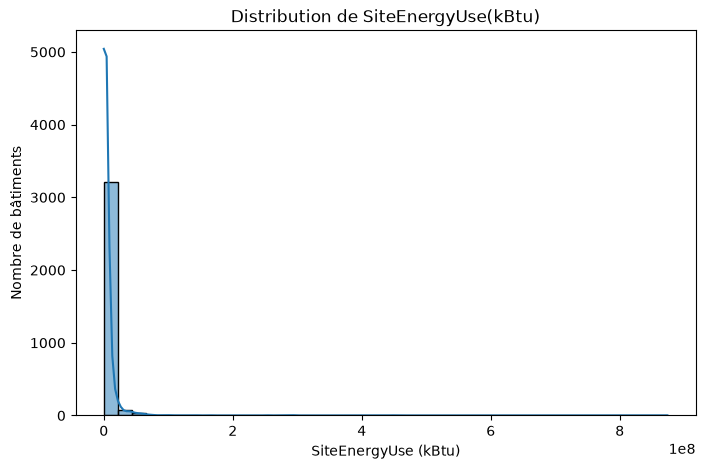

In [7]:
# Distribution de la variable cible

plt.figure(figsize=(8,5))

sns.histplot(
    df["siteenergyuse(kbtu)"],
    bins=40,
    kde=True
)

plt.title("Distribution de SiteEnergyUse(kBtu)")
plt.xlabel("SiteEnergyUse (kBtu)")
plt.ylabel("Nombre de bâtiments")

plt.show()

#### **Analyse des valeurs extrêmes**

> -  Un boxplot est utilisé afin de visualiser la présence d'éventuelles valeurs extrêmes de la variable cible.
> -  Les observations identifiées seront analysées avant toute décision de suppression, car elles peuvent correspondre à de grands bâtiments et non à des erreurs de mesure.

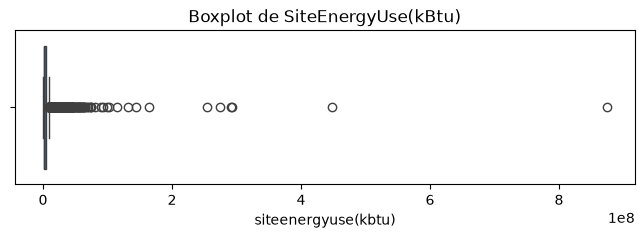

In [8]:
# Visualisation des valeurs extrêmes

plt.figure(figsize=(8, 2))

sns.boxplot(
    x=df["siteenergyuse(kbtu)"]
)

plt.title("Boxplot de SiteEnergyUse(kBtu)")

plt.show()

> -  Une matrice de corrélation de Pearson est utilisée afin d'identifier les variables numériques fortement corrélées.
> - Cette analyse permet de détecter les variables redondantes susceptibles d'apporter une information similaire au modèle

#### **Analyse de la corrélation**

> -  Les valeurs extrêmes correspondent majoritairement à des bâtiments de grande taille et font partie de la variabilité naturelle du jeu de données. Elles sont donc conservées pour la modélisation.

In [9]:
# Sélection des variables numériques

numeric_df = df.select_dtypes(include=["number"])

numeric_df.head()

,datayear,councildistrictcode,latitude,longitude,yearbuilt,numberofbuildings,numberoffloors,propertygfatotal,propertygfaparking,propertygfabuilding(s),...,thirdlargestpropertyusetypegfa,energystarscore,siteenergyuse(kbtu),totalghgemissions,ghgemissionsintensity,BuildingAge,ParkingRatio,BuildingRatio,IsMultiUse,NumberPropertyUses
0,2016,7,47.61220,-122.33799,1927,1.0,12,88434,0,88434,...,NaN,60.0,7226362.5,249.98,2.83,89,0.000000,1.000000,0,1
1,2016,7,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,...,4622.0,61.0,8387933.0,295.86,2.86,20,0.145453,0.854547,1,3
2,2016,7,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,...,NaN,43.0,72587024.0,2089.28,2.19,47,0.205748,0.794252,0,1
3,2016,7,47.61412,-122.33664,1926,1.0,10,61320,0,61320,...,NaN,56.0,6794584.0,286.43,4.67,90,0.000000,1.000000,0,1
4,2016,7,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,...,0.0,75.0,14172606.0,505.01,2.88,36,0.353115,0.646885,1,3


In [10]:
# Matrice de corrélation

corr_matrix = numeric_df.corr(method="pearson")

corr_matrix.head()

,datayear,councildistrictcode,latitude,longitude,yearbuilt,numberofbuildings,numberoffloors,propertygfatotal,propertygfaparking,propertygfabuilding(s),...,thirdlargestpropertyusetypegfa,energystarscore,siteenergyuse(kbtu),totalghgemissions,ghgemissionsintensity,BuildingAge,ParkingRatio,BuildingRatio,IsMultiUse,NumberPropertyUses
datayear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
councildistrictcode,NaN,1.000000,0.488993,-0.266815,-0.018669,-0.013213,0.250594,0.096711,0.133687,0.080936,...,0.017799,0.059775,0.040298,0.017301,0.002805,0.018669,0.125168,-0.125168,0.106887,0.117477
latitude,NaN,0.488993,1.000000,0.003416,0.117768,0.020817,-0.022826,-0.017450,-0.000782,-0.018253,...,-0.107349,0.079203,-0.021128,-0.026087,-0.040537,-0.117768,0.032087,-0.032087,-0.005519,-0.023181
longitude,NaN,-0.266815,0.003416,1.000000,-0.052976,0.017926,-0.026788,0.025564,-0.003521,0.027472,...,0.027265,-0.027284,0.033764,0.037978,0.040706,0.052976,-0.024314,0.024314,-0.027592,-0.013313
yearbuilt,NaN,-0.018669,0.117768,-0.052976,1.000000,-0.023681,0.146615,0.100352,0.183814,0.076932,...,0.091195,0.028443,0.027710,0.013209,-0.145641,-1.000000,0.224810,-0.224810,0.125958,0.095785


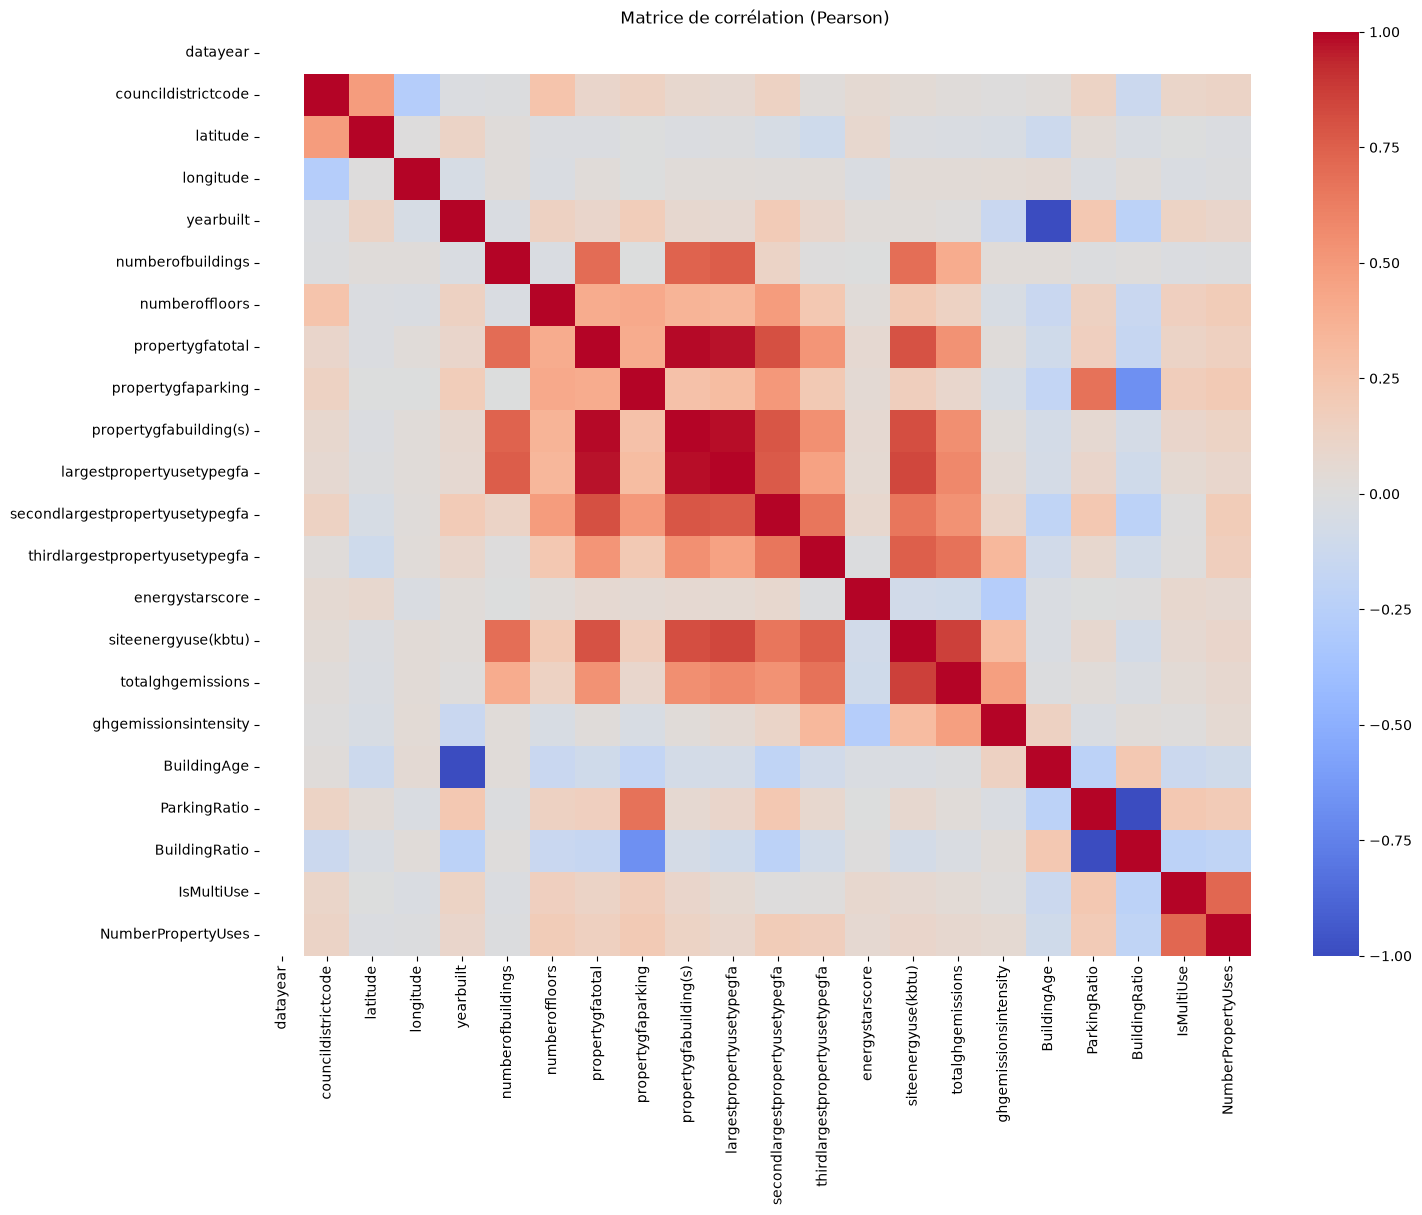

siteenergyuse(kbtu)                1.000000
totalghgemissions                  0.862722
largestpropertyusetypegfa          0.839765
propertygfabuilding(s)             0.817286
propertygfatotal                   0.801526
thirdlargestpropertyusetypegfa     0.754093
numberofbuildings                  0.690769
secondlargestpropertyusetypegfa    0.662201
ghgemissionsintensity              0.310448
numberoffloors                     0.205420
propertygfaparking                 0.171216
NumberPropertyUses                 0.099924
ParkingRatio                       0.073327
IsMultiUse                         0.062917
councildistrictcode                0.040298
longitude                          0.033764
yearbuilt                          0.027710
latitude                          -0.021128
BuildingAge                       -0.027710
BuildingRatio                     -0.073327
energystarscore                   -0.089974
datayear                                NaN
Name: siteenergyuse(kbtu), dtype

In [11]:
# Heatmap des corrélations

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation (Pearson)")

plt.show()

# Corrélations avec la variable cible

corr_target = (
    corr_matrix["siteenergyuse(kbtu)"]
    .sort_values(ascending=False)
)

display(corr_target)

> - Le boxplot met en évidence la présence de valeurs extrêmes pour **SiteEnergyUse(kBtu)**, qui sont conservées car elles représentent principalement de grands bâtiments.
> - La matrice de corrélation montre que les variables liées aux surfaces (**LargestPropertyUseTypeGFA**, **PropertyGFABuilding(s)** et **PropertyGFATotal**) sont les plus fortement corrélées avec la consommation énergétique.
> - Ces résultats seront pris en compte lors de la préparation des données et de la modélisation.

#### **Analyse des relations entre les features et la variable cible**

##### **LargestPropertyUseTypeGFA**

> - Un nuage de points est utilisé afin de visualiser la relation entre la surface principale du bâtiment (**LargestPropertyUseTypeGFA**) et la consommation énergétique (**SiteEnergyUse(kBtu)**).

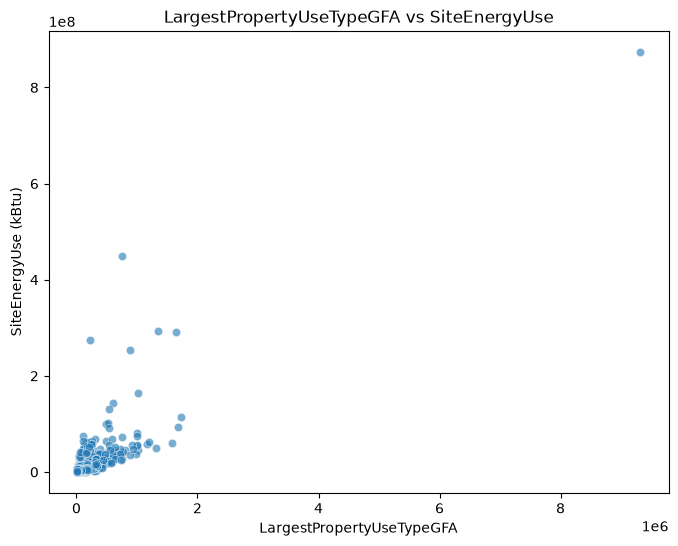

In [12]:
# Relation entre LargestPropertyUseTypeGFA et SiteEnergyUse

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="largestpropertyusetypegfa",
    y="siteenergyuse(kbtu)",
    alpha=0.6
)

plt.title("LargestPropertyUseTypeGFA vs SiteEnergyUse")
plt.xlabel("LargestPropertyUseTypeGFA")
plt.ylabel("SiteEnergyUse (kBtu)")

plt.show()

> - Le nuage de points montre une corrélation positive entre **LargestPropertyUseTypeGFA** et **SiteEnergyUse(kBtu)**.
> - Les bâtiments ayant une plus grande surface principale présentent généralement une consommation énergétique plus élevée. Quelques valeurs extrêmes sont observées, mais elles correspondent à de grands bâtiments déjà identifiés précédemment.

##### **PropertyGFATotal**

> - Un second nuage de points est réalisé afin d'observer la relation entre la surface totale du bâtiment (**PropertyGFATotal**) et la consommation énergétique.

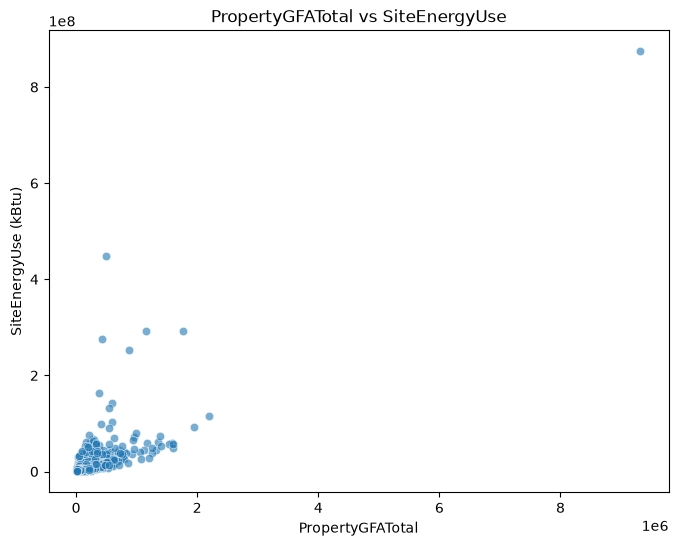

In [13]:
# Relation entre PropertyGFATotal et SiteEnergyUse

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="propertygfatotal",
    y="siteenergyuse(kbtu)",
    alpha=0.6
)

plt.title("PropertyGFATotal vs SiteEnergyUse")
plt.xlabel("PropertyGFATotal")
plt.ylabel("SiteEnergyUse (kBtu)")

plt.show()

> - Le nuage de points montre une corrélation positive entre **PropertyGFATotal** et **SiteEnergyUse(kBtu)**.
> - Les bâtiments ayant une plus grande surface totale présentent généralement une consommation énergétique plus élevée. Cette relation est cohérente avec les résultats obtenus lors de l'analyse de corrélation.

### **Séparation des variables explicatives et de la variable cible**

> Le jeu de données est séparé en :
>  - **X** : les variables explicatives utilisées pour entraîner le modèle ;
>  - **y** : la variable cible (**SiteEnergyUse(kBtu)**).

In [14]:
# Séparation des variables explicatives (X) et de la cible (y)

X = df.drop(
    columns=[
        "siteenergyuse(kbtu)",
        "totalghgemissions"
    ]
)

y = df["siteenergyuse(kbtu)"]

print(f"Dimensions de X : {X.shape}")
print(f"Dimensions de y : {y.shape}")

Dimensions de X : (3348, 32)
Dimensions de y : (3348,)


### **Encodage des variables catégorielles**

>  - Les variables catégorielles sont encodées à l'aide de **OneHotEncoder** afin de les rendre exploitables par les modèles de Machine Learning.
>  - Cette méthode évite d'introduire un ordre artificiel entre les différentes catégories.

In [15]:
# Identification des variables catégorielles

categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print(f"Nombre de variables catégorielles : {len(categorical_features)}")
categorical_features

Nombre de variables catégorielles : 11


['buildingtype',
 'primarypropertytype',
 'neighborhood',
 'listofallpropertyusetypes',
 'largestpropertyusetype',
 'secondlargestpropertyusetype',
 'thirdlargestpropertyusetype',
 'yearsenergystarcertified',
 'compliancestatus',
 'outlier',
 'usage_type']

In [16]:
# Suppression des variables administratives

X = X.drop(columns=[
    "compliancestatus",
    "outlier"
])

print(f"Dimensions de X : {X.shape}")

Dimensions de X : (3348, 30)


In [17]:
# Mise à jour des variables catégorielles

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Nombre de variables catégorielles : {len(categorical_features)}")
categorical_features

Nombre de variables catégorielles : 9


C:\Users\FR103217\AppData\Local\Temp\ipykernel_35720\3347460103.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


['buildingtype',
 'primarypropertytype',
 'neighborhood',
 'listofallpropertyusetypes',
 'largestpropertyusetype',
 'secondlargestpropertyusetype',
 'thirdlargestpropertyusetype',
 'yearsenergystarcertified',
 'usage_type']

In [18]:
print(f"Dimensions de X : {X.shape}")

Dimensions de X : (3348, 30)


### **Application du OneHotEncoder**

>  - Les variables catégorielles sont transformées en variables numériques à l'aide de **OneHotEncoder**.
>  - Cette étape permet aux algorithmes de Machine Learning de traiter correctement les différentes catégories sans introduire de relation d'ordre entre elles.

In [19]:
# Préprocessement des variables catégorielles

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

### **Conclusion de la préparation des features**

- Cinq nouvelles variables ont été créées afin d'enrichir le jeu de données.
- Les variables peu pertinentes et celles susceptibles d'introduire du **data leakage** ont été supprimées.
- Les variables explicatives (**X**) et la variable cible (**y**) ont été séparées.
- Les variables catégorielles ont été préparées pour être encodées avec **OneHotEncoder** avant l'entraînement des modèles.

Le jeu de données est désormais prêt pour la phase de modélisation.

> * Les cinq premiers et 5 derniéres enregistrements correspondent à des hôtels situés à Seattle (WA) en 2016. 
> * Ils illustrent les principales variables du jeu de données : localisation, caractéristiques du bâtiment, consommation énergétique et émissions de gaz à effet de serre.


In [24]:
# Suppression des variables non pertinentes pour la modélisation

columns_to_remove = [
    "compliancestatus",
    "outlier",
    "yearsenergystarcertified"
]

df = df.drop(columns=columns_to_remove)

print(df.shape)

KeyError: "['compliancestatus', 'outlier', 'yearsenergystarcertified'] not found in axis"

In [25]:
print(df.columns.tolist())

['datayear', 'buildingtype', 'primarypropertytype', 'councildistrictcode', 'neighborhood', 'latitude', 'longitude', 'yearbuilt', 'numberofbuildings', 'numberoffloors', 'propertygfatotal', 'propertygfaparking', 'propertygfabuilding(s)', 'listofallpropertyusetypes', 'largestpropertyusetype', 'largestpropertyusetypegfa', 'secondlargestpropertyusetype', 'secondlargestpropertyusetypegfa', 'thirdlargestpropertyusetype', 'thirdlargestpropertyusetypegfa', 'energystarscore', 'siteenergyuse(kbtu)', 'defaultdata', 'totalghgemissions', 'ghgemissionsintensity', 'usage_type', 'BuildingAge', 'ParkingRatio', 'BuildingRatio', 'IsMultiUse', 'NumberPropertyUses']


### **Sauvegarde du jeu de données**

In [26]:
from pathlib import Path

# Création du dossier
Path("../data/processed").mkdir(parents=True, exist_ok=True)

# Sauvegarde du jeu de données préparé
df.to_csv(
    "../data/processed/buildings_model.csv",
    index=False
)

print("Jeu de données préparé sauvegardé avec succès.")

Jeu de données préparé sauvegardé avec succès.
